# Práctica 3: Visualización de datos

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)

PATH_INPUT = "../data/processed/spotify_cleaned.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

AUDIO_COLS = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
]

## 0. Carga de datos

In [2]:
df = pd.read_csv(PATH_INPUT)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas.")
df.head()

Dimensiones: 66174 filas x 36 columnas.


,unnamed_0,uri,rank,artist_names,artists_num,artist_individual,artist_id,artist_genre,artist_img,collab,track_name,release_date,album_num_tracks,album_cover,source,peak_rank,previous_rank,weeks_on_chart,streams,week,danceability,energy,key,mode,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,country,region,language,pivot
0,29477,spotify:track:4ZtFanR9U6ndgddUvNcjcG,1,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,good 4 u,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,1,1,3,3612666,03-06-2021,0.563,0.664,9,1,-5.044,0.1540,0.335,0.000000,0.0849,0.6880,166.928,178147,Australia,Oceania,English,0
1,29478,spotify:track:6HU7h9RYOaPRFeh0R3UeAr,3,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,deja vu,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,2,2,9,1666474,03-06-2021,0.442,0.612,2,1,-7.222,0.1120,0.584,0.000006,0.3700,0.1780,180.917,215507,Australia,Oceania,English,0
2,29479,spotify:track:5CZ40GBx1sQ9agT82CLQCT,4,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,traitor,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,4,6,2,1433290,03-06-2021,0.380,0.339,3,1,-7.885,0.0338,0.691,0.000000,0.1200,0.0849,100.607,229227,Australia,Oceania,English,0
3,29480,spotify:track:5wANPM4fQCJwkGd4rN57mH,6,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,drivers license,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,1,5,21,1266266,03-06-2021,0.561,0.431,10,1,-8.810,0.0578,0.768,0.000014,0.1060,0.1370,143.875,242013,Australia,Oceania,English,0
4,29481,spotify:track:5JCoSi02qi3jJeHdZXMmR8,7,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,favorite crime,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,7,15,2,1184068,03-06-2021,0.369,0.272,9,1,-10.497,0.0364,0.866,0.000000,0.1470,0.2180,172.929,152667,Australia,Oceania,English,0


## 1. Histogramas: distribución de las variables de audio

Se generan histogramas para las 9 variables de audio (`AUDIO_COLS`) mediante un ciclo `zip(axes.flat, AUDIO_COLS)` que recorre la lista de columnas y llena automáticamente una cuadrícula de subplots de 3x3.

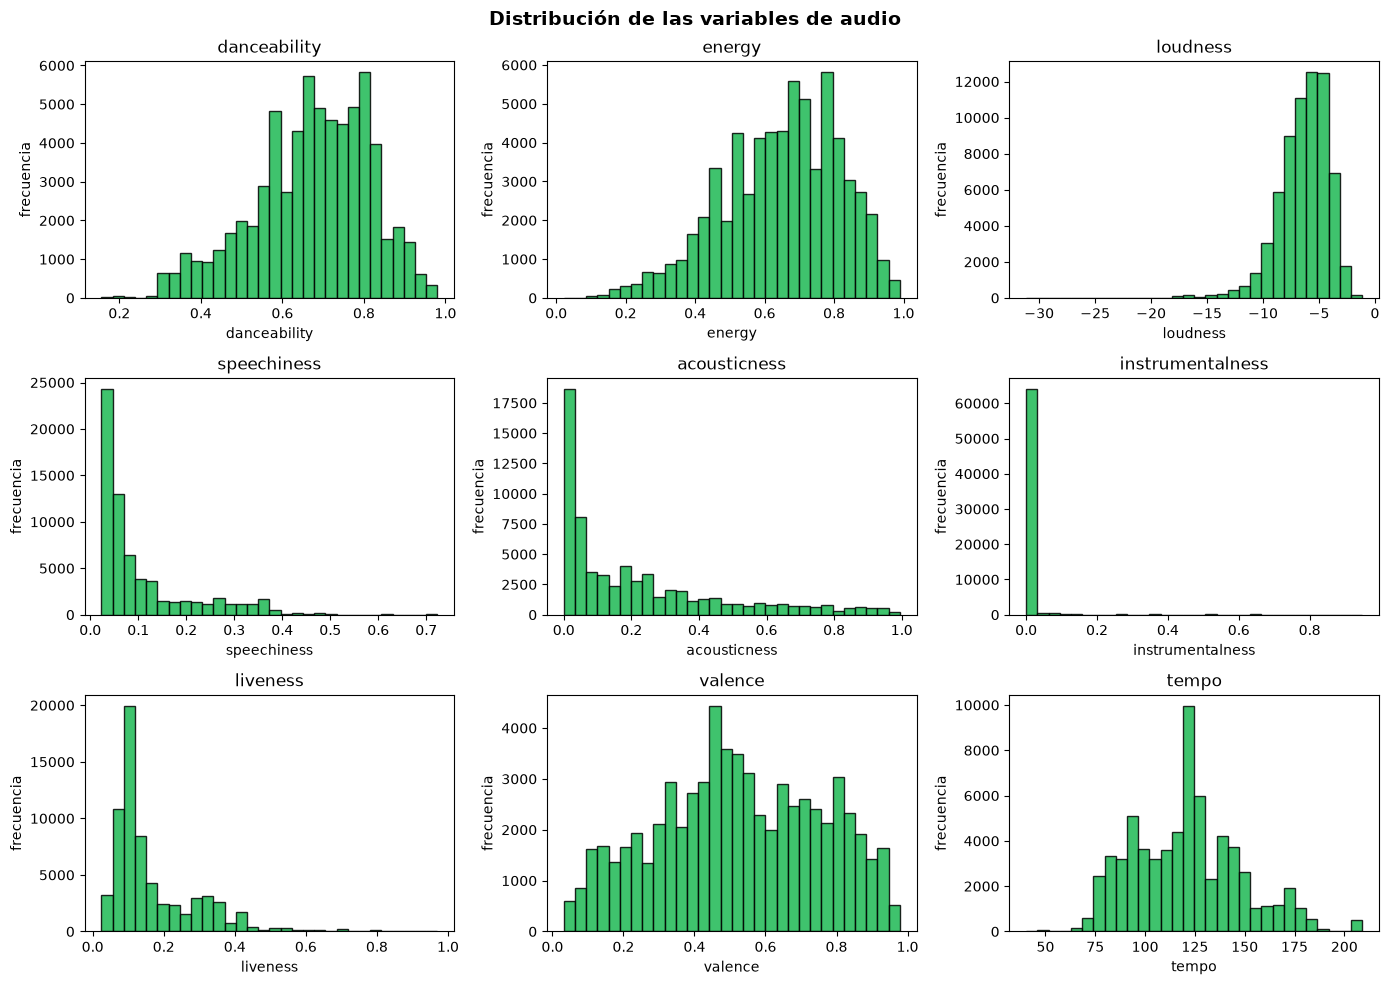

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, AUDIO_COLS):
    ax.hist(df[col], bins=30, color="#1DB954", edgecolor="black", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("frecuencia")

fig.suptitle("Distribución de las variables de audio", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "histogramas_audio.png"), dpi=150)
plt.show()

Podemos observar que `danceability` y `energy` se concentran en valores medios-altos con forma casi acampanada, `loudness` está sesgada hacia la derecha (la mayoría de canciones son "fuertes", cerca de 0 dB), y `speechiness`, `acousticness`, `instrumentalness` y `liveness` están fuertemente sesgadas hacia la izquierda, lo que confirma lo visto en la Práctica 2: son variables donde la mayoría de canciones tienen valores bajos y solo unas pocas son atípicas (canciones muy habladas, muy acústicas o instrumentales).

## 2. Diagramas de caja: variables de audio y streams por país

Se comparan 6 variables (`box_cols`) entre los 3 países del dataset. Un ciclo recorre la lista de columnas, construye por país una lista de series (`data`) y dibuja un boxplot por subplot.

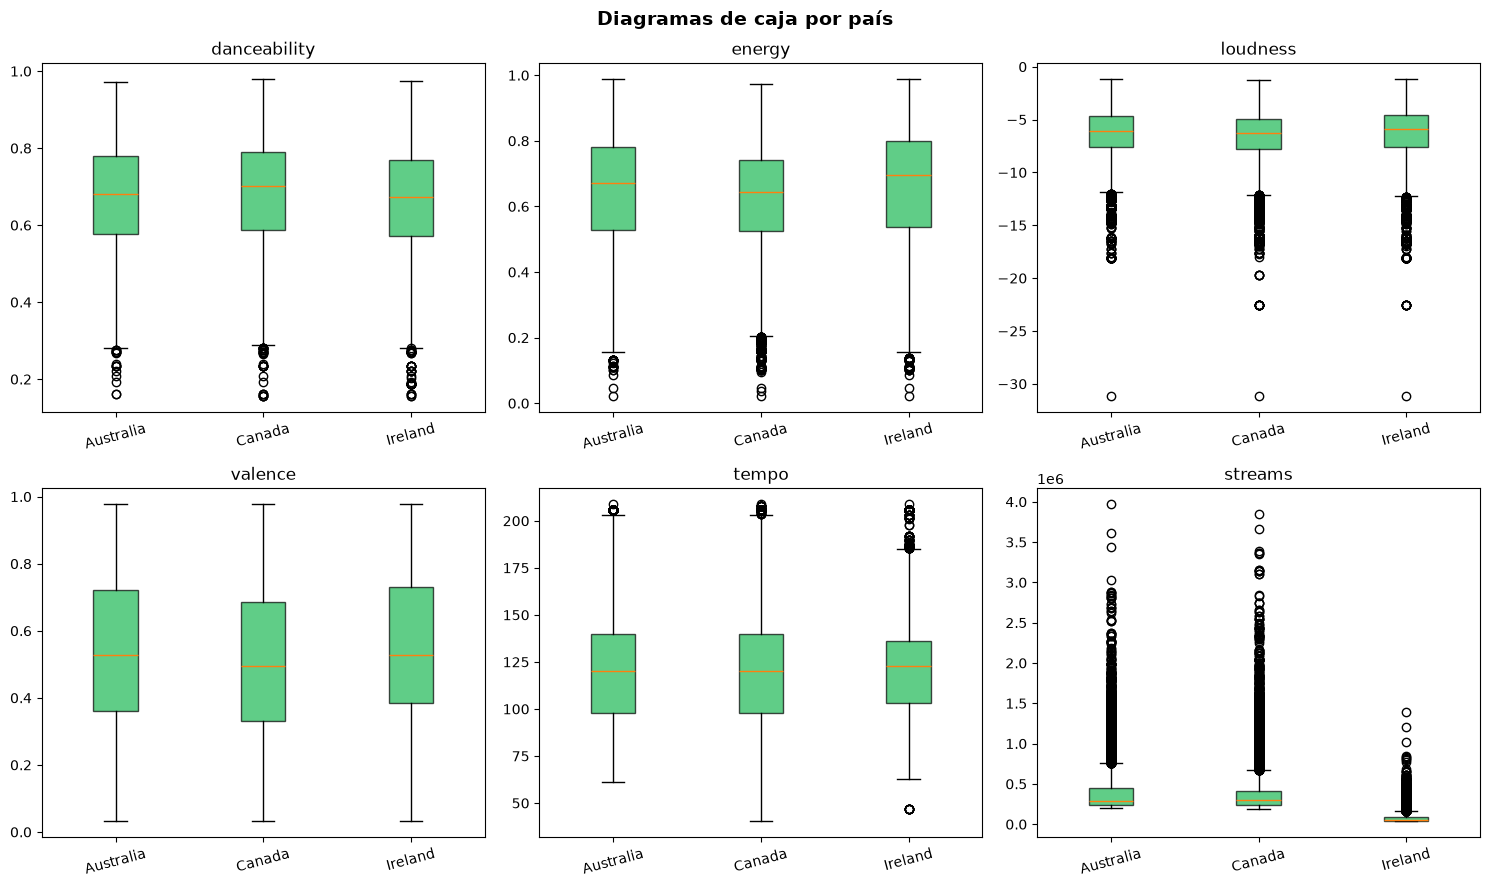

In [4]:
box_cols = ["danceability", "energy", "loudness", "valence", "tempo", "streams"]
countries = sorted(df["country"].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flat, box_cols):
    data = [df.loc[df["country"] == c, col] for c in countries]
    ax.boxplot(data, tick_labels=countries, patch_artist=True,
               boxprops=dict(facecolor="#1DB954", alpha=0.7))
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Diagramas de caja por país", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "boxplots_pais.png"), dpi=150)
plt.show()

Las cajas de `danceability`, `energy`, `loudness`, `valence` y `tempo` son muy parecidas entre los 3 países, lo que indica que el "sonido" de las canciones populares no cambia mucho por región. En cambio `streams` muestra una diferencia clara: Canadá y Australia tienen medianas y cajas mucho más altas que Irlanda, con varios valores atípicos, esto es coherente con el promedio de streams por país calculado en la Práctica.

## 3. Diagramas de dispersión: relaciones entre variables

Se definen 4 pares de variables (`pares`) y, mediante un doble ciclo (uno sobre los pares y otro interno sobre los países), se grafica cada par coloreado por país.

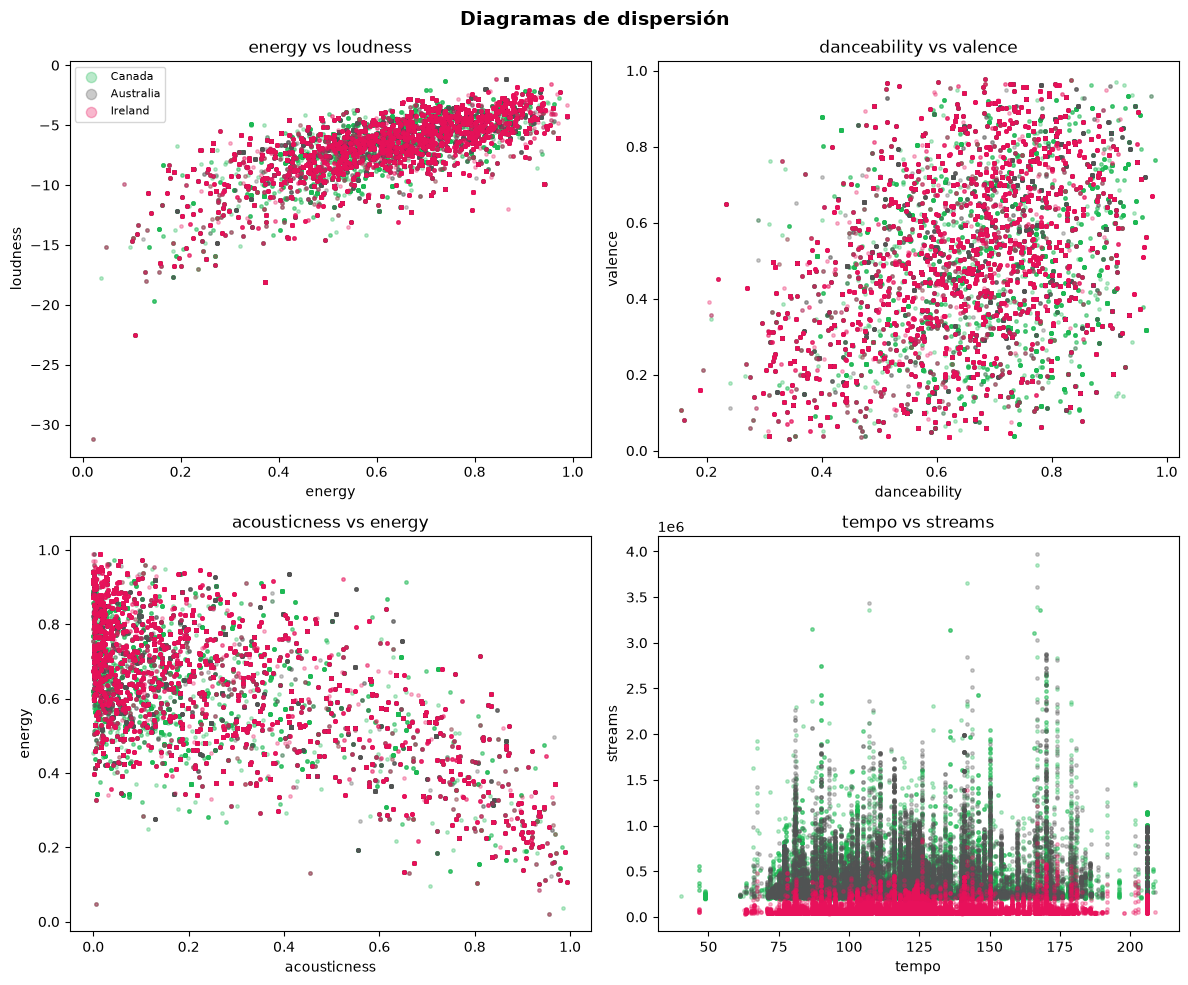

In [5]:
pares = [
    ("energy", "loudness"),
    ("danceability", "valence"),
    ("acousticness", "energy"),
    ("tempo", "streams"),
]
colores = {"Canada": "#1DB954", "Australia": "#535353", "Ireland": "#E8115B"}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (x, y) in zip(axes.flat, pares):
    for pais, color in colores.items():
        sub = df[df["country"] == pais]
        ax.scatter(sub[x], sub[y], s=6, alpha=0.3, color=color, label=pais)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x} vs {y}")

axes[0, 0].legend(markerscale=3, fontsize=8)
fig.suptitle("Diagramas de dispersión", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "dispersion.png"), dpi=150)
plt.show()

`energy` vs `loudness` muestra la relación positiva más clara de las 4: a mayor energía, mayor volumen. `danceability` vs `valence` también tiene una tendencia positiva moderada. `acousticness` vs `energy` muestra una relación inversa: las canciones acústicas tienden a tener poca energía. `tempo` vs `streams` no muestra ningún patrón, la nube de puntos está dispersa en todo el rango de tempo sin importar el número de streams, lo que confirma una correlación casi nula (0.05) del tempo con los streams.

## 4. Diagramas de pastel: composición de variables categóricas

Se define una función `top_categorias` que agrupa las categorías menos frecuentes en "otros", y un ciclo recorre 3 variables categóricas (país, género de artista y sello/curador de playlist) dibujando un pastel para cada una.

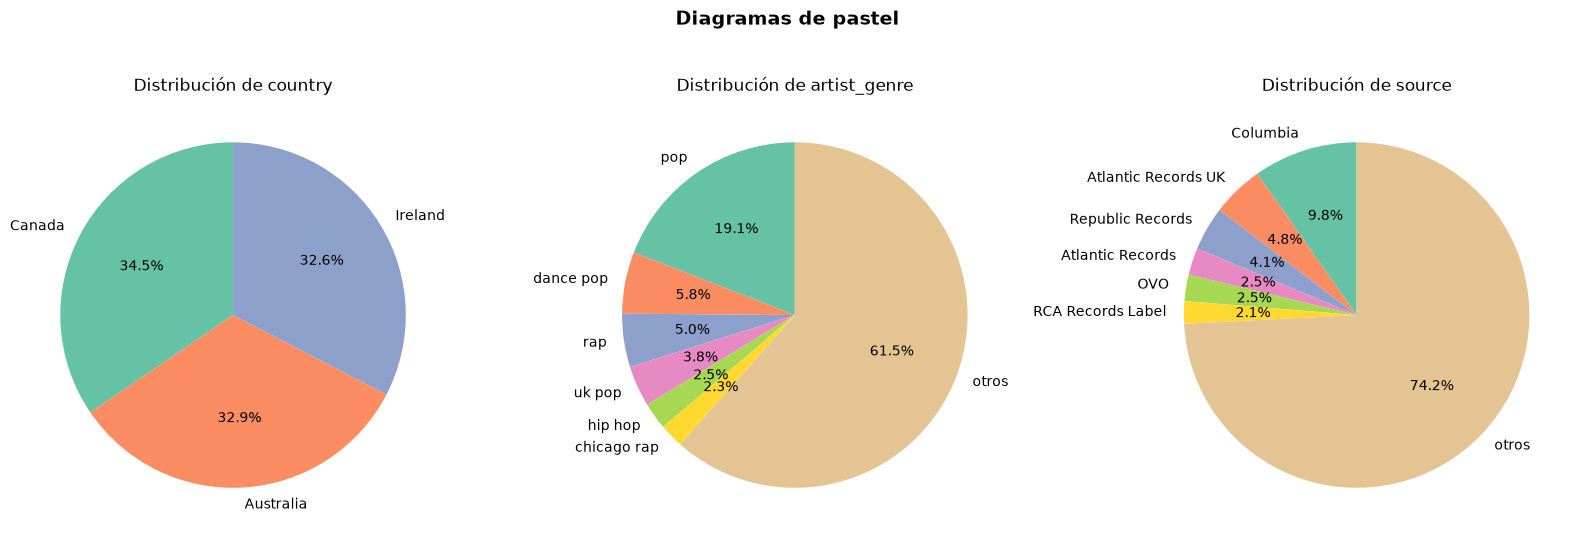

In [6]:
def top_categorias(serie, n=6):
    conteo = serie.value_counts()
    top = conteo.head(n)
    otros = conteo.iloc[n:].sum()
    if otros > 0:
        top = pd.concat([top, pd.Series({"otros": otros})])
    return top

specs_pastel = [
    ("country", df["country"], 6),
    ("artist_genre", df.loc[df["artist_genre"] != "0", "artist_genre"], 6),
    ("source", df["source"], 6),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (nombre, serie, n) in zip(axes, specs_pastel):
    datos = top_categorias(serie, n)
    ax.pie(datos, labels=datos.index, autopct="%1.1f%%", startangle=90,
           colors=plt.cm.Set2.colors)
    ax.set_title(f"Distribución de {nombre}")

fig.suptitle("Diagramas de pastel", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "pasteles.png"), dpi=150)
plt.show()

El dataset está bastante balanceado entre los 3 países (cerca de un tercio cada uno, con Canadá ligeramente arriba con 34.5%). En géneros, `pop` es el más frecuente de forma individual (19.1%) pero está muy repartido entre 456 géneros distintos catalogados, por lo que "otros" concentra el 61.5% restante. En sellos/curadores tampoco hay uno solo que domine: `Columbia` es el más frecuente pero solo alcanza un 9.8% del total, y el 74.2% de las filas quedan en "otros", lo que refleja lo fragmentada que está la industria discográfica detrás de las canciones del chart.

## 5. Diagramas de violín: forma de la distribución por país

Se grafican 4 variables de audio (`violin_cols`) mediante un ciclo que, para cada variable, arma la lista de datos por país y dibuja un violín por subplot, coloreando cada cuerpo con el mismo estilo.

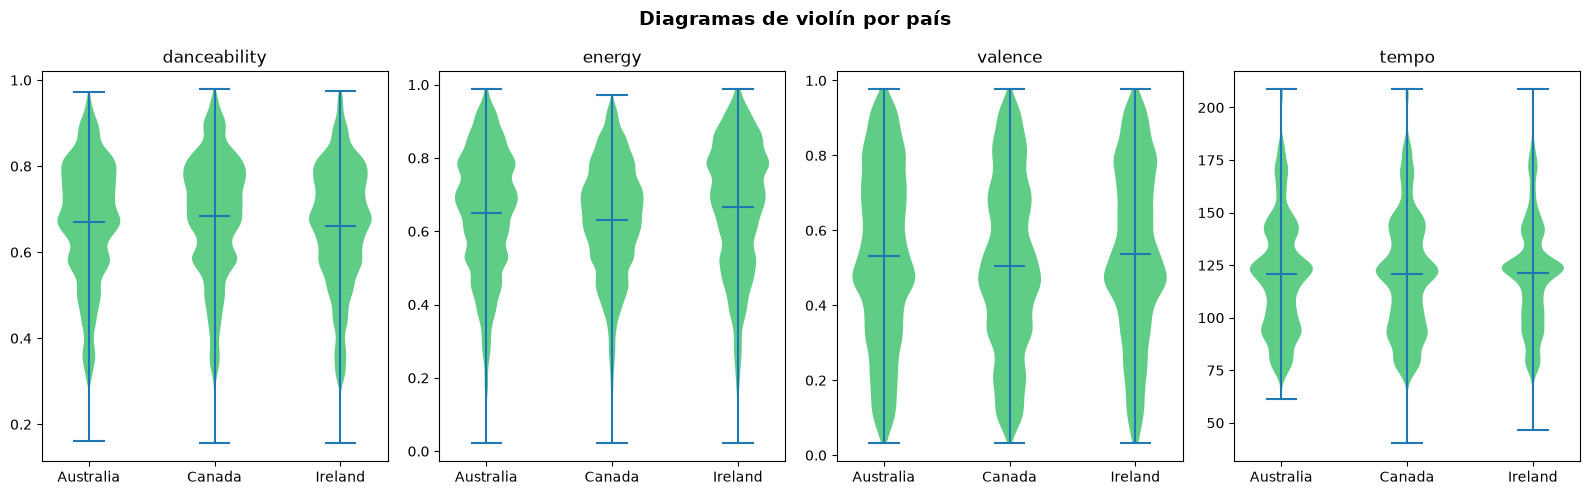

In [7]:
violin_cols = ["danceability", "energy", "valence", "tempo"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, violin_cols):
    data = [df.loc[df["country"] == c, col] for c in countries]
    partes = ax.violinplot(data, showmeans=True)
    for cuerpo in partes["bodies"]:
        cuerpo.set_facecolor("#1DB954")
        cuerpo.set_alpha(0.7)
    ax.set_xticks(range(1, len(countries) + 1))
    ax.set_xticklabels(countries)
    ax.set_title(col)

fig.suptitle("Diagramas de violín por país", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "violines_pais.png"), dpi=150)
plt.show()

Los violines confirman lo visto en los diagramas de caja: la forma de la distribución de `danceability`, `energy`, `valence` y `tempo` es prácticamente la misma entre Canadá, Australia e Irlanda (mismo ancho, mismos "abultamientos"), reforzando que el tipo de canciones que llegan al top de streaming es similar entre estos 3 países, sin importar que Irlanda tenga muchos menos streams totales.